In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

base_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\6HS"
analytical_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\semi-analytic_100MHz"
postprocess_folder = os.path.join(base_folder, "postprocess")

In [24]:
def receiver_line_plot(datasets, quantities, postprocess_folder, fname, orientation='Endfire',
                    suptitle=None, color_list=None):
    # Styling constants
    font_suptitle = 24
    font_label    = 18
    font_tick     = 18
    font_legend   = 15
    normal_lw     = 2.5

    # colors = ['#000000', '#d62728',  '#1f77b4', '#6a0dad', "#0e0ace", "#ff00b3"]

    # Analytical curves (draw first, underneath)
    fixed_styles = {
        'Evert': {
            'color':    '#000000',
            'linestyle':'-',
            'linewidth': normal_lw * 1.5,
            'zorder':   1,
            'label': 'Analytical Solution'
        },
        'empymod - 2001 DLF': {
            'color':    '#4B2E05',  # brown
            'linestyle':'--',
            'linewidth': normal_lw * 1.5,
            'zorder':   1,
            'label': 'empymod - 2001 DLF'
        }
    }

    # Build variable source list preserving order
    all_sources = []
    seen = set()
    for ds in datasets:
        src = ds[6]
        if src not in seen:
            all_sources.append(src)
            seen.add(src)
    variable_sources = [s for s in all_sources if s not in fixed_styles]

    # High-impact, colorblind-safe palette
    palette = [
    "#1f77b4",  # Blue
    "#d62728",  # Red
    "#2ca02c",  # Green
    "#e66100",  # Carrot Orange (improved)
    "#17becf",  # Teal
    "#9467bd",  # Purple
    "#bcbd22",  # Yellow-Green
    "#1fa2ff",  # Sky Blue
    "#ff6f61",  # Coral
    "#40e0d0",  # Turquoise
    ]

    # Linestyle cycle
    linestyles = [
        '--',         # dashed
        '-.',         # dash-dot
        (0, (1, 1)),  # dense dots
        (0, (3, 1, 1, 1)),  # dash-dot pattern
        (0, (5, 1)),  # long dash, short gap
        ':',          # dotted
    ]
    
    # Assign colors and styles to variable sources
    origin_styles = {**fixed_styles}
    for idx, src in enumerate(variable_sources):
        color = palette[color_list[idx] % len(palette)] if color_list else palette[idx % len(palette)]
        ls = linestyles[idx % len(linestyles)]
        origin_styles[src] = {
            'color':     color,
            'linestyle': ls,
            'linewidth': normal_lw,
            'alpha':     1.0,
            'zorder':    3 + idx
        }

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for j, (title, ylabel) in enumerate(quantities):
        ax = axes[j//2, j%2]

        # Plot analytical curves
        for src, style in fixed_styles.items():
            try:
                ds = next(d for d in datasets if d[6] == src)
            except StopIteration:
                continue
            y = [ds[0], ds[1], ds[2], ds[3]][j]
            x = ds[5]
            plot_fn = ax.semilogy if j == 0 else ax.plot
            ln, = plot_fn(x, y,
                          color=style['color'],
                          linestyle=style['linestyle'],
                          linewidth=style['linewidth'],
                          zorder=style['zorder'],
                            label=style['label'])
            ln.set_path_effects([
                pe.Stroke(linewidth=style['linewidth']+2, foreground='white'),
                pe.Normal()
            ])

        # Plot variable curves
        for ds in datasets:
            src = ds[6]
            if src in fixed_styles:
                continue
            y = [ds[0], ds[1], ds[2], ds[3]][j]
            x = ds[5]
            style = origin_styles[src]
            plot_fn = ax.semilogy if j == 0 else ax.plot
            plot_fn(x, y,
                    label=src,
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=style['linewidth']*0.8,
                    alpha=style['alpha'],
                    zorder=style['zorder'])

        # Grid, labels, legend
        ax.grid(True, which='both' if j == 0 else 'major', linestyle='--', linewidth=0.5)
        ax.set_title(title, fontsize=font_label, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=font_label)
        if j//2 == 1:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
        if j == 3:
            ax.legend(fontsize=font_legend, loc='lower right')

    # Suptitle & save
    fig.suptitle(suptitle, fontsize=font_suptitle, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
    print(f"Saved plot to {os.path.join(postprocess_folder, fname)}")
    plt.show()

def compute_errors(ref, elfe):
    errors = []
    for idx in range(4):  # amp, phase, real, imag
        ref_data = ref[idx]
        elfe_data = elfe[idx]
        if idx in [0, 2, 3]:
            with np.errstate(divide='ignore', invalid='ignore'):
                err = np.abs(elfe_data - ref_data) / np.abs(ref_data)
                err[~np.isfinite(err)] = np.nan
        else:
            err = elfe_data - ref_data
        errors.append(err)
    errors.append(elfe[5])
    return tuple(errors)

def receiver_line_error_plot(datasets, reference_dataset, quantities, postprocess_folder, fname, orientation='Endfire',
                             suptitle=None, color_list=None):
    # Styling constants
    font_suptitle = 24
    font_label    = 18
    font_tick     = 18
    font_legend   = 15
    normal_lw     = 2.5

    # Analytical curves (draw first, underneath)
    fixed_styles = {
        'Evert': {
            'color':    '#000000',
            'linestyle':'-',
            'linewidth': normal_lw * 1.5,
            'zorder':   1,
            'label': 'Analytical Solution'
        },
        'empymod - 2001 DLF': {
            'color':    '#4B2E05',  # brown
            'linestyle':'--',
            'linewidth': normal_lw * 1.5,
            'zorder':   1,
            'label': 'empymod - 2001 DLF'
        }
    }

    # Build variable source list preserving order
    all_sources = []
    seen = set()
    for ds in datasets:
        src = ds[6]
        if src not in seen:
            all_sources.append(src)
            seen.add(src)
    variable_sources = [s for s in all_sources if s not in fixed_styles]

    # High-impact, colorblind-safe palette
    palette = [
    "#1f77b4",  # Blue
    "#d62728",  # Red
    "#2ca02c",  # Green
    "#e66100",  # Carrot Orange (improved)
    "#17becf",  # Teal
    "#9467bd",  # Purple
    "#bcbd22",  # Yellow-Green
    "#1fa2ff",  # Sky Blue
    "#ff6f61",  # Coral
    "#40e0d0",  # Turquoise
    ]

    # Linestyle cycle
    linestyles = [
        '--',         # dashed
        '-.',         # dash-dot
        (0, (1, 1)),  # dense dots
        (0, (3, 1, 1, 1)),  # dash-dot pattern
        (0, (5, 1)),  # long dash, short gap
        ':',          # dotted
    ]
    
    # Assign colors and styles to variable sources
    origin_styles = {**fixed_styles}
    for idx, src in enumerate(variable_sources):
        color = palette[color_list[idx] % len(palette)] if color_list else palette[idx % len(palette)]
        ls = linestyles[idx % len(linestyles)]
        origin_styles[src] = {
            'color':     color,
            'linestyle': ls,
            'linewidth': normal_lw,
            'alpha':     1.0,
            'zorder':    3 + idx
        }

    # Compute amplitude error range for ylims
    amp_errors = []
    for ds in datasets:
        src = ds[6]
        if src in fixed_styles:
            continue
        ref_data = reference_dataset[0]
        elfe_data = ds[0]
        with np.errstate(divide='ignore', invalid='ignore'):
            err = np.abs(elfe_data - ref_data) / np.abs(ref_data)
            err[~np.isfinite(err)] = np.nan
        amp_errors.append(err)
    amp_errors = np.array(amp_errors)
    amp_min = np.nanmin(amp_errors)
    amp_max = np.nanmax(amp_errors)


    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for j, (title, ylabel) in enumerate(quantities):
        ax = axes[j//2, j%2]

        # Plot errors for variable curves
        for ds in datasets:
            src = ds[6]
            if src in fixed_styles:
                continue
            ref_data = reference_dataset[j]
            elfe_data = ds[j]
            if j in [0, 2, 3]:
                with np.errstate(divide='ignore', invalid='ignore'):
                    err = np.abs(elfe_data - ref_data) / np.abs(ref_data)
                    err[~np.isfinite(err)] = np.nan
                ax.set_title(f"Normalized Error in {title}", fontsize=font_label, fontweight='bold')
            else:
                err = elfe_data - ref_data
                ax.set_title(f"Error in {title}", fontsize=font_label, fontweight='bold')
            x = ds[5]
            style = origin_styles[src]
            plot_fn = ax.semilogy if j != 1 else ax.plot
            plot_fn(x, err,
                    label=f"{src}",
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=style['linewidth']*0.8,
                    alpha=style['alpha'],
                    zorder=style['zorder'])
        ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
        ax.grid(True, which='both' if j != 1 else 'major', linestyle='--', linewidth=0.5)
        ax.set_ylabel('Error', fontsize=font_label)
        if j//2 == 1:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
        if j == 3:
            ax.legend(fontsize=font_legend, loc='lower right')
        if j != 1:
            ax.set_ylim(amp_min, amp_max)
        else:
            ax.set_ylim(-0.1, 0.1)

    # Suptitle & save
    fig.suptitle(suptitle, fontsize=font_suptitle, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
    plt.show()

In [25]:
def receiver_line_combined(dataset,
                           analytical_dataset,
                           quantities,
                           postprocess_folder,
                           fname,
                           orientation='Endfire',
                           suptitle=None,
                           normal_color='#1f77b4',
                           error_color='#ff7f0e',
                           analytical_label='Semi-Analytical Quadrature'):
    """
    Plots 4 quantities in a 2×4 grid:
      - Row 1: Normal curves (analytical + dataset)
      - Row 2: Error curves (dataset vs analytical)
    Quantities should be a list of 4 tuples: (title, ylabel).
    Both dataset and analytical_dataset are lists/arrays with indices matching quantities,
    and index 5 holds the x-axis (distance).

    Phase curve is automatically placed in the 4th column regardless of its position in `quantities`.
    """
    # Styling
    fs_title  = 24
    fs_label  = 18
    fs_tick   = 14
    fs_legend = 14
    lw        = 2.5

    ncols = len(quantities)  # should be 4
    fig, axes = plt.subplots(2, ncols, figsize=(6*ncols, 10), sharex='col')  # wider columns

    x_data = dataset[5]
    x_anal = analytical_dataset[5]

    # Determine ordering: move Phase to last column
    phase_idx = next((i for i, (t, _) in enumerate(quantities) if 'Phase' in t), None)
    if phase_idx is None:
        ordered = list(range(ncols))
    else:
        ordered = [i for i in range(ncols) if i != phase_idx] + [phase_idx]

    # Precompute global error limits for normalized errors vs analytical
    all_norm_errs = []
    for j in [i for i in ordered if i in (0, 2, 3)]:
        y_ref = analytical_dataset[j]
        y_src = dataset[j]
        with np.errstate(divide='ignore', invalid='ignore'):
            err = np.abs(y_src - y_ref) / np.abs(y_ref)
            err[~np.isfinite(err)] = np.nan
        all_norm_errs.append(err)
    all_norm_errs = np.hstack(all_norm_errs)
    ymin, ymax = np.nanmin(all_norm_errs), np.nanmax(all_norm_errs)

    # subplot labels (a)-(h), rowwise
    subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

    for col, j in enumerate(ordered):
        title, ylabel = quantities[j]

        # — Top row: normal plot —
        ax_norm = axes[0, col]

        # Add subplot label
        ax_norm.text(-0.12, 1.08, subplot_labels[col], transform=ax_norm.transAxes,
                     fontsize=fs_label, fontweight='bold', va='top', ha='left')

        # Analytical curve
        y_anal = analytical_dataset[j]
        if j == 0:
            lines = ax_norm.semilogy(x_anal, y_anal,
                                     color='black', linestyle='-',
                                     linewidth=lw*1.5,
                                     label=analytical_label, zorder=2)
        else:
            lines = ax_norm.plot(x_anal, y_anal,
                                  color='black', linestyle='-',
                                  linewidth=lw*1.5,
                                  label=analytical_label, zorder=2)
        ln = lines[0]
        ln.set_path_effects([
            pe.Stroke(linewidth=lw*1.5 + 2, foreground='white'),
            pe.Normal()
        ])

        # Dataset curve
        y_dat = dataset[j]
        if j == 0:
            ax_norm.semilogy(x_data, y_dat,
                             color=normal_color, linestyle='--',
                             linewidth=lw, label='empymod - 2001 DLF', zorder=3)
        else:
            ax_norm.plot(x_data, y_dat,
                         color=normal_color, linestyle='--',
                         linewidth=lw, label='empymod - 2001 DLF', zorder=3)

        ax_norm.set_title(title, fontsize=fs_label, fontweight='bold')
        ax_norm.set_ylabel(ylabel, fontsize=fs_label)
        ax_norm.grid(True, which='both' if j == 0 else 'major', linestyle='--', linewidth=0.5)
        ax_norm.tick_params(labelsize=fs_tick)
        if col == 0:
            ax_norm.legend(fontsize=fs_legend, loc='best')

        # — Bottom row: error plot —
        ax_err = axes[1, col]
        # Add subplot label
        ax_err.text(-0.12, 1.08, subplot_labels[ncols + col], transform=ax_err.transAxes,
                    fontsize=fs_label, fontweight='bold', va='top', ha='left')

        y_ref = analytical_dataset[j]
        y_src = dataset[j]

        if j in [0, 2, 3]:
            # normalized error
            with np.errstate(divide='ignore', invalid='ignore'):
                err = np.abs(y_src - y_ref) / np.abs(y_ref)
                err[~np.isfinite(err)] = np.nan
            err_title = f"Normalized Error in {title}"
        else:
            # absolute error
            err = y_src - y_ref
            err_title = f"Error in {title}"

        if j != 1:
            ax_err.semilogy(x_data, err,
                             color=error_color, linestyle='-',
                             linewidth=lw, label='Error', zorder=3)
        else:
            ax_err.plot(x_data, err,
                        color=error_color, linestyle='-',
                        linewidth=lw, label='Error', zorder=3)

        ax_err.axhline(0, linestyle='--', linewidth=1, color='gray')
        ax_err.set_title(err_title, fontsize=fs_label, fontweight='bold')
        ax_err.set_ylabel('Error', fontsize=fs_label)
        ax_err.grid(True, which='both' if j != 4 else 'major', linestyle='--', linewidth=0.5)
        ax_err.tick_params(labelsize=fs_tick)
        if col == 0:
            ax_err.legend(fontsize=fs_legend, loc='best')

        # apply global y-limits for normalized-error axes
        if j in [0, 2, 3]:
            ax_err.set_ylim(ymin, ymax)

    # common x-label
    for ax in axes[1, :]:
        ax.set_xlabel('Distance (m)', fontsize=fs_label)

    # Suptitle, layout & save
    fig.suptitle(suptitle, fontsize=fs_title, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
    print(f"Saved combined plot to {os.path.join(postprocess_folder, fname)}")
    plt.show()


In [26]:
def receiver_line_combined_multi(datasets,
                                 analytical_dataset,
                                 quantities,
                                 postprocess_folder,
                                 fname,
                                 orientation='Endfire',
                                 suptitle=None,
                                 color_list=None,
                                 analytical_label='Analytical Solution'):
    """
    Plots 4 quantities in a 2×4 grid for multiple datasets:
      - Row 1: Normal curves (analytical + all datasets)
      - Row 2: Error curves (each dataset vs analytical)
    `datasets` is a list of tuples/lists with entries [amp, real, imag, phase, ..., x_data, source_name].
    `quantities` is a list of 4 (title, ylabel).  Index 5 in each dataset is x.
    Phase curve is automatically placed in the 4th column, subplots labeled (a)-(h), and styling applied.
    Real and Imag error axes share amplitude error limits, and Phase error is clipped to ±0.1.
    """
    # Styling constants
    fs_title   = 24
    fs_label   = 18
    fs_tick    = 14
    fs_legend  = 14
    lw         = 2.5

    ncols = len(quantities)
    fig, axes = plt.subplots(2, ncols, figsize=(6*ncols, 10), sharex='col')

    # extract x-axis
    x_anal = analytical_dataset[5]

    # reorder so Phase is last
    phase_idx = next((i for i, (t, _) in enumerate(quantities) if 'Phase' in t), None)
    ordered = list(range(ncols)) if phase_idx is None else [i for i in range(ncols) if i != phase_idx] + [phase_idx]

    # fixed analytical style
    ana_style = {'color':'black', 'linestyle':'-', 'linewidth':lw*1.5, 'zorder':1, 'label':analytical_label}

    # palette and linestyles
    palette = ["#1f77b4","#d62728","#2ca02c","#e66100","#17becf","#9467bd","#bcbd22","#1fa2ff","#ff6f61","#40e0d0"]
    linestyles = ['--','-.',(0,(1,1)),(0,(3,1,1,1)),(0,(5,1)),':']

    # collect sources
    sources = [ds[6] for ds in datasets]

    # assign styles to each source, safe on color_list length
    source_styles = {}
    for idx, src in enumerate(sources):
        col = palette[color_list[idx] % len(palette)] if (color_list and idx < len(color_list)) else palette[idx % len(palette)]
        ls = linestyles[idx % len(linestyles)]
        source_styles[src] = {'color':col, 'linestyle':ls, 'linewidth':lw, 'alpha':1.0, 'label':src, 'zorder':2+idx}

    # subplot labels a-h
    subplot_labels = [f'({c})' for c in list('abcdefgh')[:2*ncols]]

    # compute global amplitude normalized error limits
    amp_errs = []
    for ds in datasets:
        y_src = ds[0]
        y_ref = analytical_dataset[0]
        with np.errstate(divide='ignore', invalid='ignore'):
            err = np.abs(y_src - y_ref)/np.abs(y_ref)
            err[~np.isfinite(err)] = np.nan
        amp_errs.append(err)
    amp_min, amp_max = np.nanmin(np.hstack(amp_errs)), np.nanmax(np.hstack(amp_errs))

    # compute global normalized limits for imag but not needed separately

    # plotting loop
    for col, j in enumerate(ordered):
        title, ylabel = quantities[j]
        # top row
        ax = axes[0, col]
        ax.text(-0.12, 1.08, subplot_labels[col], transform=ax.transAxes,
                fontsize=fs_label, fontweight='bold', va='top')
        # analytical
        y_ana = analytical_dataset[j]
        plot_fn = ax.semilogy if j == 0 else ax.plot
        ln = plot_fn(x_anal, y_ana, **ana_style)[0]
        ln.set_path_effects([pe.Stroke(linewidth=ana_style['linewidth']+2, foreground='white'), pe.Normal()])
        # dataset curves
        for ds in datasets:
            y = ds[j]
            style = source_styles[ds[6]]
            plot_fn(x_anal, y, **style)
        ax.set_title(title, fontsize=fs_label, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=fs_label)
        ax.grid(True, which='both' if j == 0 else 'major', linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=fs_tick)
        if col == 0:
            ax.legend(fontsize=fs_legend, loc='best')

        # bottom row
        ax = axes[1, col]
        ax.text(-0.12, 1.08, subplot_labels[ncols + col], transform=ax.transAxes,
                fontsize=fs_label, fontweight='bold', va='top')
        for ds in datasets:
            y_src = ds[j]
            y_ref = analytical_dataset[j]
            if j in [0, 2, 3]:  # amplitude & imag normalized
                with np.errstate(divide='ignore', invalid='ignore'):
                    err = np.abs(y_src - y_ref)/np.abs(y_ref)
                    err[~np.isfinite(err)] = np.nan
                etitle = f"Normalized Error in {title}"
            else:  # real absolute error
                err = y_src - y_ref
                etitle = f"Error in {title}"
            # Use semilogy for all but the last column (phase error), which uses plot
            fn = ax.semilogy if col != ncols - 1 else ax.plot
            fn(x_anal, err,
               color=source_styles[ds[6]]['color'],
               linestyle=source_styles[ds[6]]['linestyle'],
               linewidth=source_styles[ds[6]]['linewidth'],
               alpha=source_styles[ds[6]]['alpha'],
               label=source_styles[ds[6]]['label'],
               zorder=source_styles[ds[6]]['zorder'])
        ax.axhline(0, linestyle='--', linewidth=1, color='gray')
        ax.set_title(etitle, fontsize=fs_label, fontweight='bold')
        ax.set_ylabel('Error', fontsize=fs_label)
        ax.grid(True, which='both' if j != 4 else 'major', linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=fs_tick)
        if col == 0:
            ax.legend(fontsize=fs_legend, loc='best')
        # apply clipping
        if j in [1, 2, 3, 4]:  # real and imag clip to amplitude error bounds
            ax.set_ylim(amp_min, amp_max)
        if col == ncols - 1 and j == 1:
            ax.set_ylim(-0.55, 0.5)

    # x-labels
    for ax in axes[1, :]:
        ax.set_xlabel('Distance (m)', fontsize=fs_label)

    fig.suptitle(suptitle, fontsize=fs_title, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
    print(f"Saved combined multi plot to {os.path.join(postprocess_folder, fname)}")
    plt.show()


## Half-Space Theory: CMP

In [27]:
analytical_file = os.path.join(analytical_folder, "Exx_single_freq_4_100MHz.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)

# Broadside
abs_broadside = analytical_lines[:, 5]
real_broadside = -1*analytical_lines[:, 7]
imag_broadside = -1*analytical_lines[:, 8]
phase_broadside = np.arctan2(imag_broadside, real_broadside)

# Oblique
abs_45deg = analytical_lines[:, 9]
real_45deg = -1*analytical_lines[:, 11]
imag_45deg = -1*analytical_lines[:, 12]
phase_45deg = np.arctan2(imag_45deg, real_45deg)

dataset_evert = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'Evert'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'Evert'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'Evert')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

analytical_file = os.path.join(analytical_folder, "GPR-2001-4-dlf.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)

# Broadside
abs_broadside = analytical_lines[:, 5]
real_broadside = -1*analytical_lines[:, 7]
imag_broadside = -1*analytical_lines[:, 8]
phase_broadside = np.arctan2(imag_broadside, real_broadside)

# Oblique
abs_45deg = analytical_lines[:, 9]
real_45deg = -1*analytical_lines[:, 11]
imag_45deg = -1*analytical_lines[:, 12]
phase_45deg = np.arctan2(imag_45deg, real_45deg)

dataset_empymod = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'empymod - 2001 DLF'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'empymod - 2001 DLF'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'empymod - 2001 DLF')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

electric_file = os.path.join(base_folder, "out_HF_l1d_l2PML_CMP_BA", "electric_fields_receiver_line.txt")
e_data_elfe_1 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_HF_l1d_l2PML_CMP_BK", "electric_fields_receiver_line.txt")
e_data_elfe_2 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_HF_l1d_l2PML_CMP_F", "electric_fields_receiver_line.txt")
e_data_elfe_3 = np.loadtxt(electric_file)

e_data_elfe_all = [e_data_elfe_1, e_data_elfe_2, e_data_elfe_3]

labels = [
    r'Uniform $k_\text{min}$ Stretch',
    r'Uniform $k_\text{max}$ Stretch',
    r'Varying Stretch',
    ]

# Allow custom number of receivers for each data set
num_rec_ef_list = [256] * len(e_data_elfe_all)
num_rec_bs_list = [0] * len(e_data_elfe_all)
num_rec_ob_list = [0] * len(e_data_elfe_all)

dataset_elfe_4 = []
for i, e_data_elfe in enumerate(e_data_elfe_all):
    num_rec_ef = num_rec_ef_list[i]

    rec_x_elfe = e_data_elfe[:, 0]
    rec_y_elfe = e_data_elfe[:, 1]
    real_Ex_elfe = e_data_elfe[:, 4]
    imag_Ex_elfe = e_data_elfe[:, 5]
    abs_Ex_elfe = np.abs(real_Ex_elfe + 1j * imag_Ex_elfe)
    phase_Ex_elfe = np.angle(real_Ex_elfe + 1j * imag_Ex_elfe)

    # Endfire
    i_rx_ef = 0
    abs_ef = abs_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    phase_ef = phase_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    real_ef = real_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    imag_ef = imag_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    r_ef = rec_x_elfe[i_rx_ef:i_rx_ef + num_rec_ef]

    dataset_elfe_4.append((abs_ef, phase_ef, real_ef, imag_ef, 'Endfire', r_ef, labels[i]))

# Use datasets from Evert, empymod, and elfe for Endfire
datasets_4 = [ds for ds in dataset_evert + dataset_empymod if ds[4] == 'Endfire']
datasets_4 += dataset_elfe_4


Saved combined plot to F:\Projects\EMGeoInversion\Tests_Thesis\6HS\postprocess\1_cmp_elfe_evert_all.png


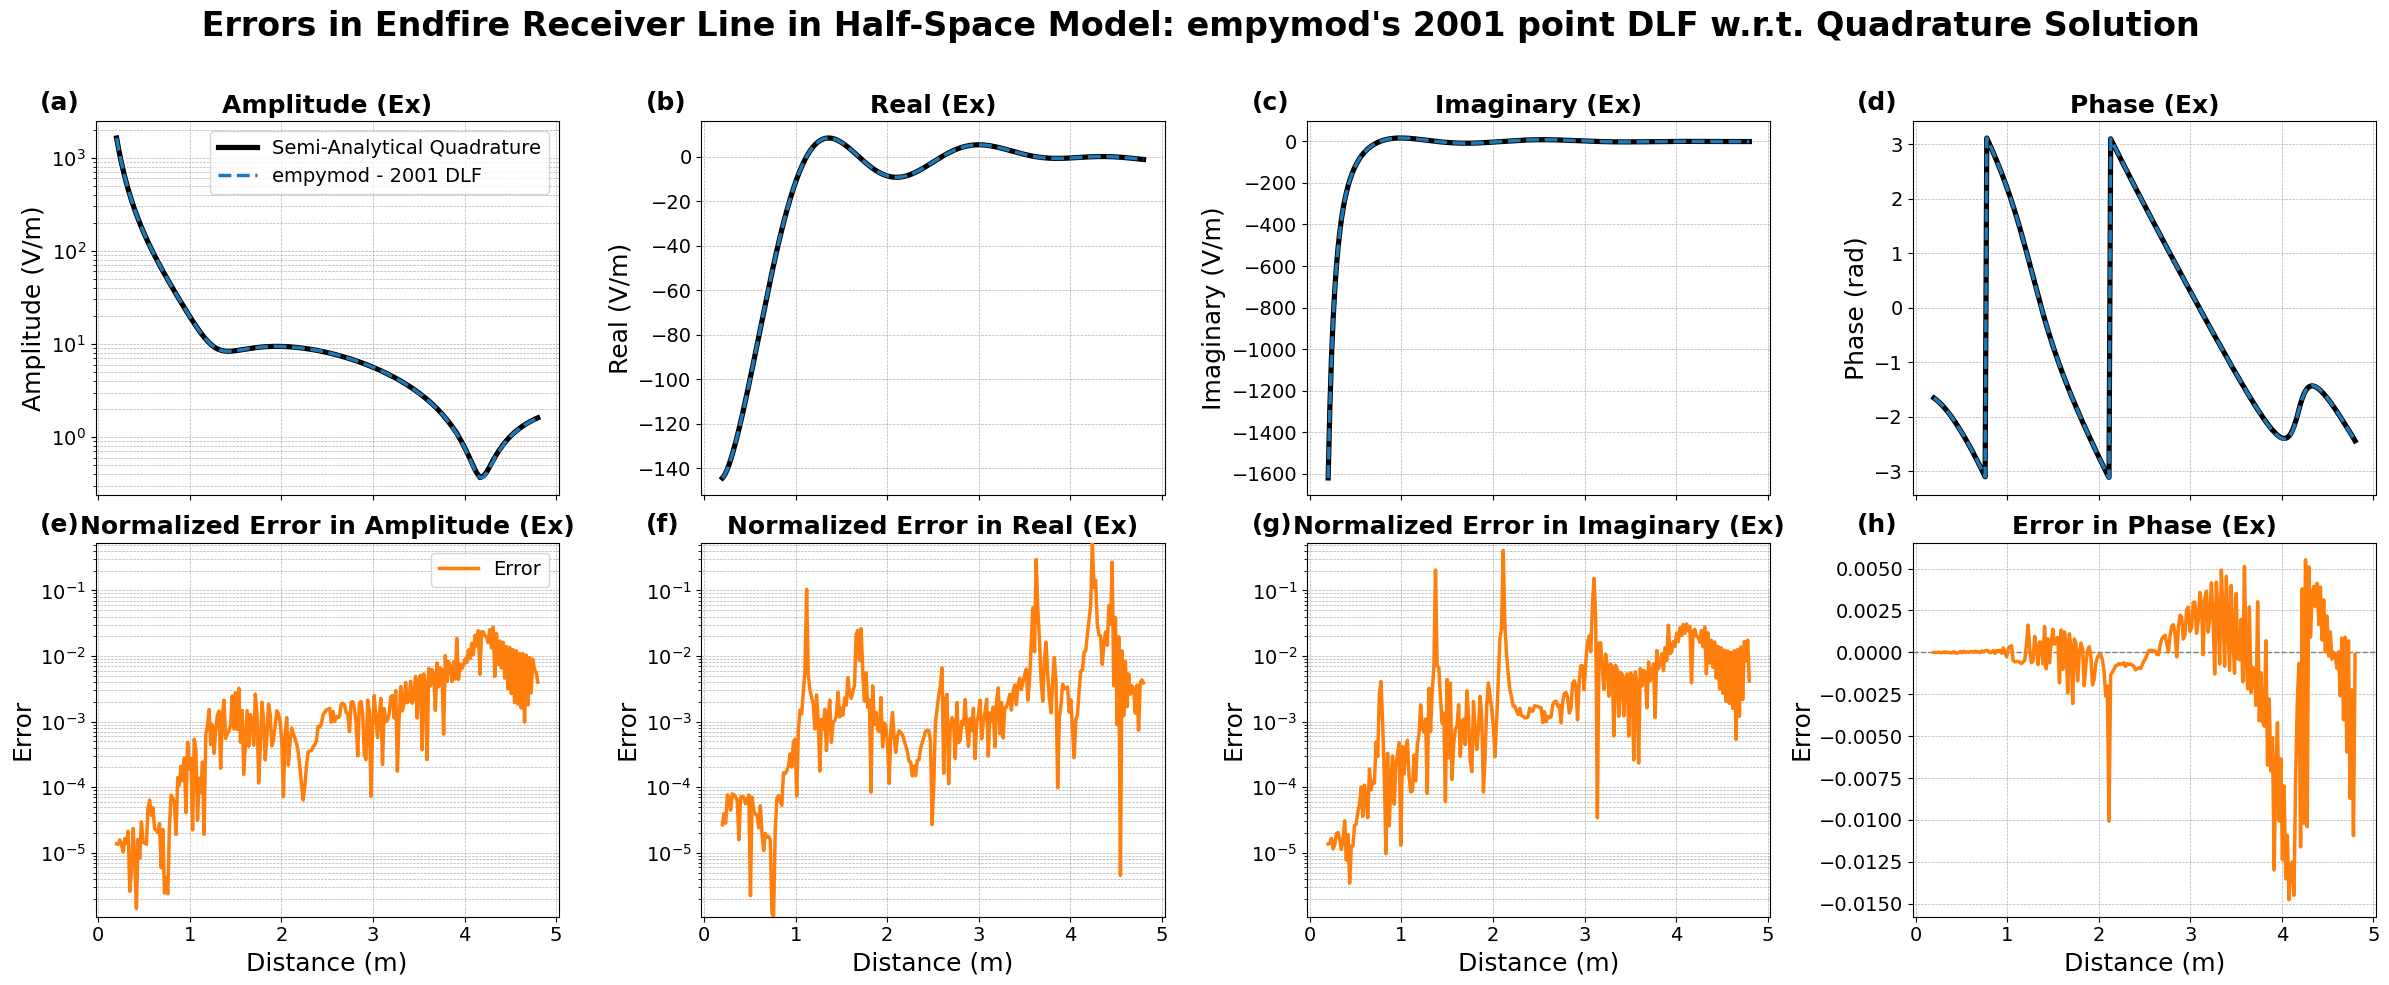

Saved combined multi plot to F:\Projects\EMGeoInversion\Tests_Thesis\6HS\postprocess\1_cmp_elfe_evert_all_multi.png


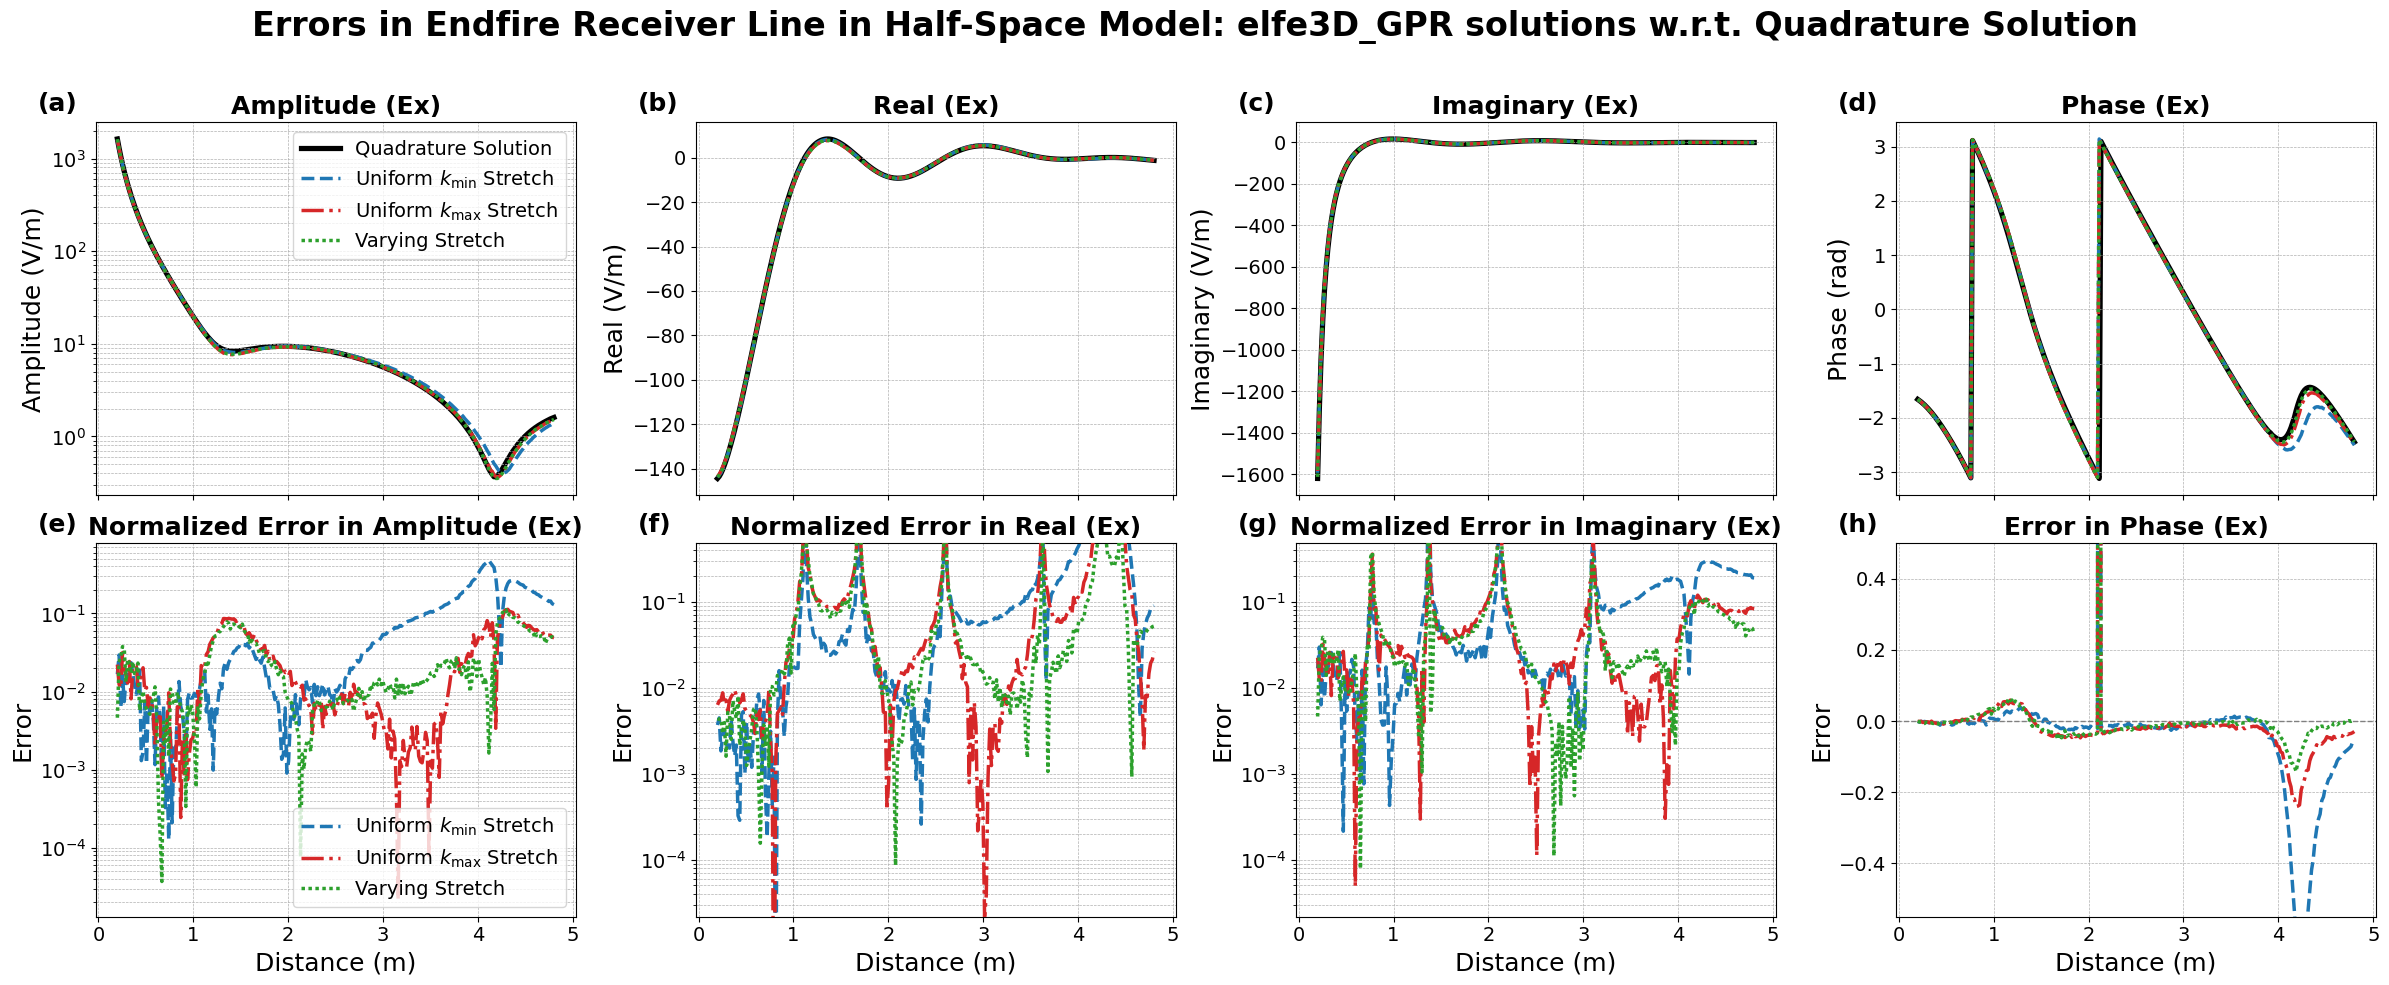

In [28]:
orientation = 'Endfire'

receiver_line_combined(
    dataset_empymod[0],
    dataset_evert[0],
    quantities, 
    postprocess_folder, 
    fname=f"1_cmp_elfe_evert_all.png", 
    orientation=orientation, 
    suptitle=f" Errors in {orientation} Receiver Line in Half-Space Model: empymod's 2001 point DLF w.r.t. Quadrature Solution", 
)

orientation = 'Endfire'

receiver_line_combined_multi(
    dataset_elfe_4,
    dataset_evert[0],
    quantities,
    postprocess_folder,
    fname=f"1_cmp_elfe_evert_all_multi.png",
    orientation=orientation,
    suptitle=f"Errors in {orientation} Receiver Line in Half-Space Model: elfe3D_GPR solutions w.r.t. Quadrature Solution",
    color_list=[0, 1, 2],
    analytical_label='Quadrature Solution',
)

Saved plot to F:\Projects\EMGeoInversion\Tests_Thesis\6HS\postprocess\1_cmp.png


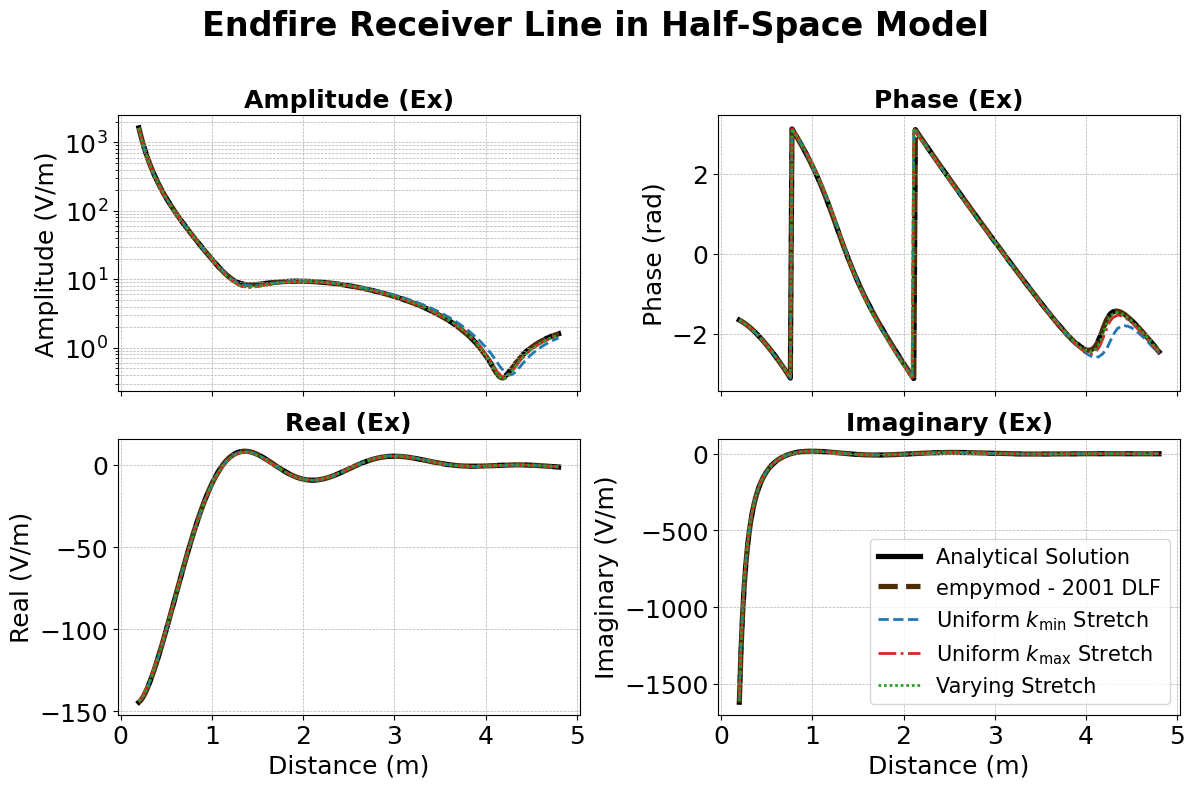

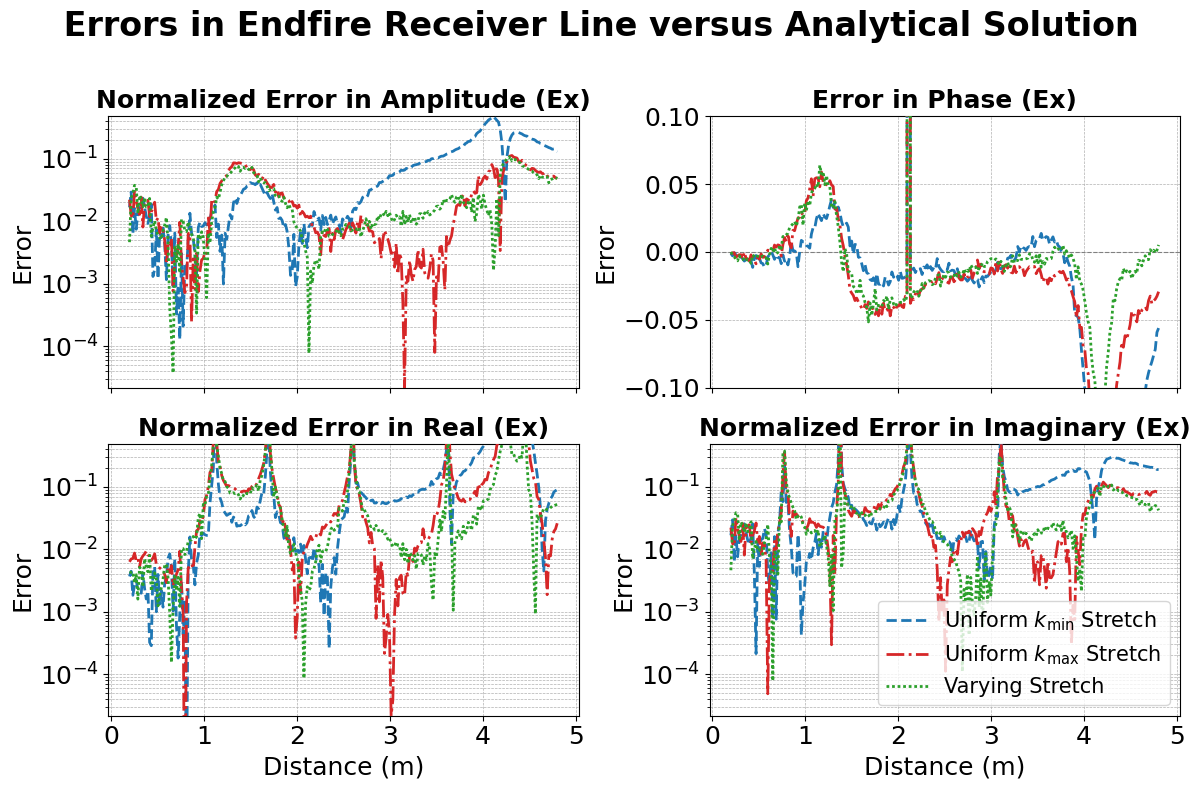

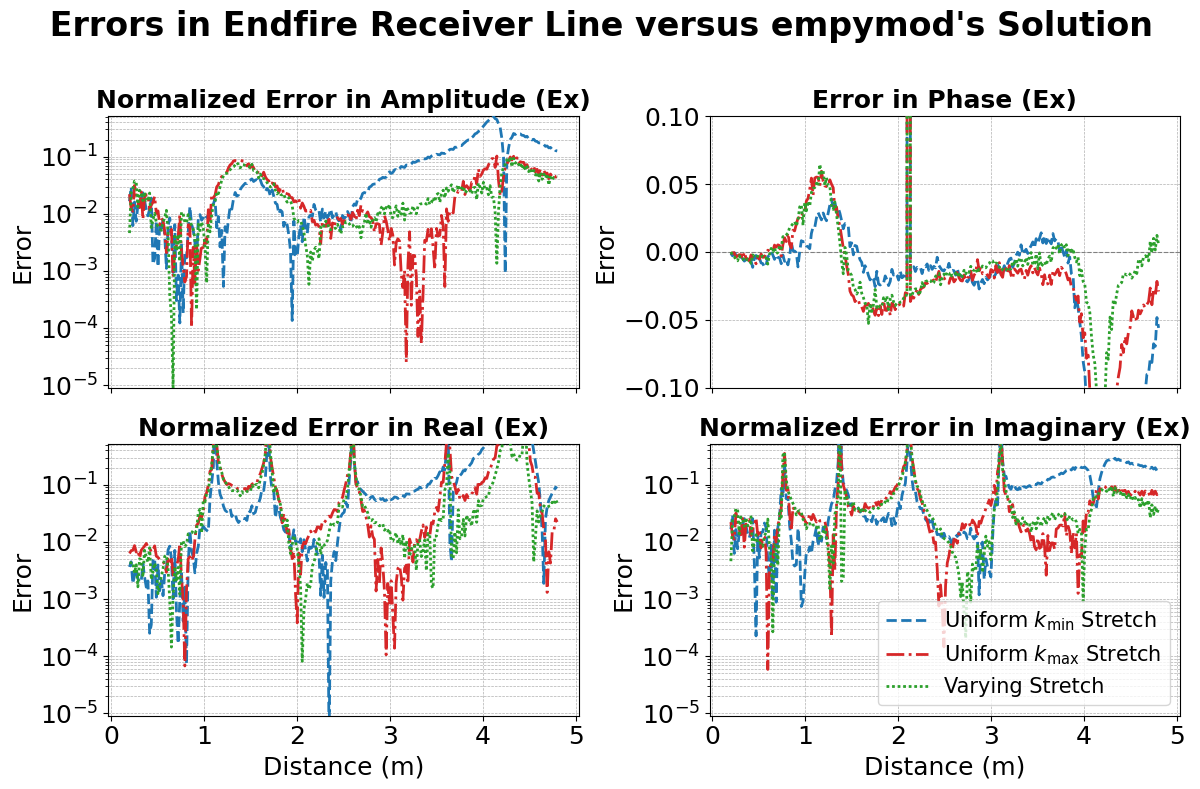

In [16]:
orientation = 'Endfire'
fname = f"1_cmp.png"
receiver_line_plot(datasets_4, 
                quantities, 
                postprocess_folder, 
                fname=fname, 
                orientation=orientation, 
                suptitle=f"{orientation} Receiver Line in Half-Space Model", 
                color_list=[0,1,2])

fname = f"1_cmp_error.png"
receiver_line_error_plot(datasets_4,
                dataset_evert[0],  # Use Evert as reference
                quantities, 
                postprocess_folder, 
                fname=fname, 
                orientation=orientation, 
                suptitle=f" Errors in {orientation} Receiver Line versus Analytical Solution", 
                color_list=[0,1,2])

fname = f"1_cmp_erroremp.png"
receiver_line_error_plot(datasets_4,
                dataset_empymod[0],  # Use Evert as reference
                quantities, 
                postprocess_folder, 
                fname=fname, 
                orientation=orientation, 
                suptitle=f" Errors in {orientation} Receiver Line versus empymod's Solution", 
                color_list=[0,1,2])

## Half-Space Theory: CO

Saved plot to F:\Projects\EMGeoInversion\Tests_Thesis\6HS\postprocess\2_co.png


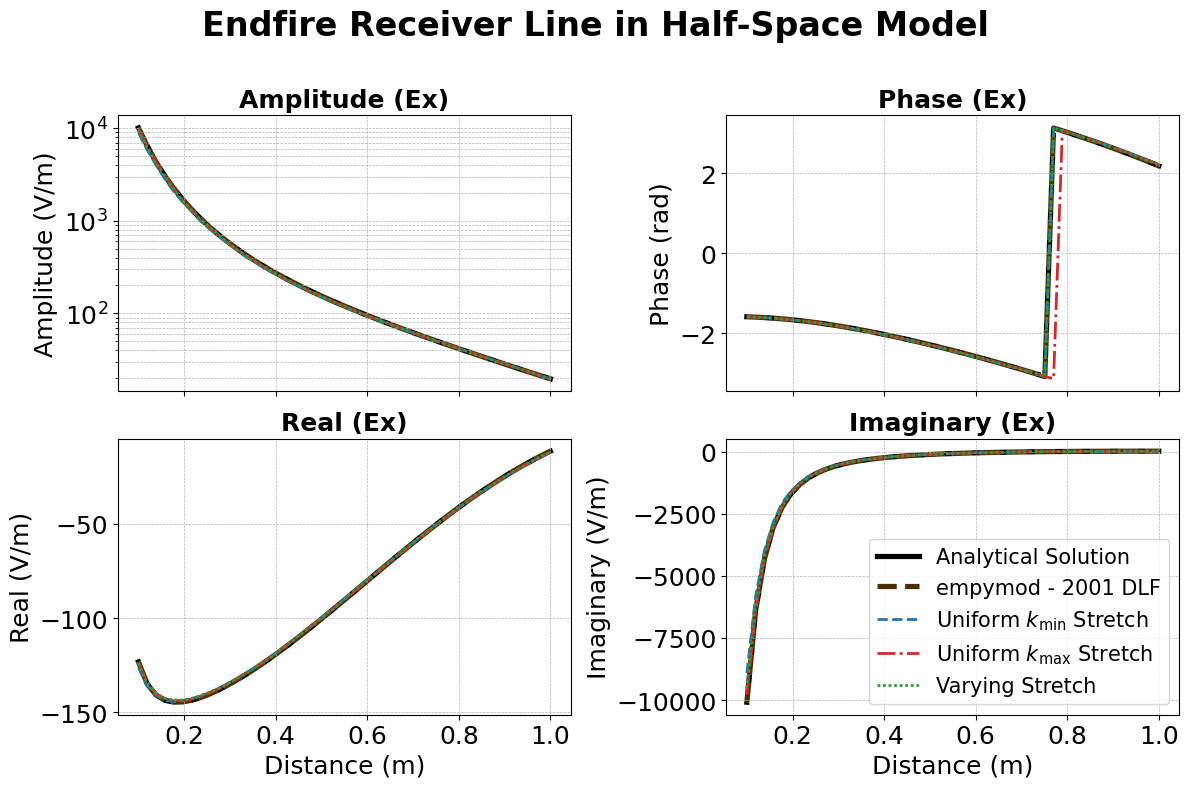

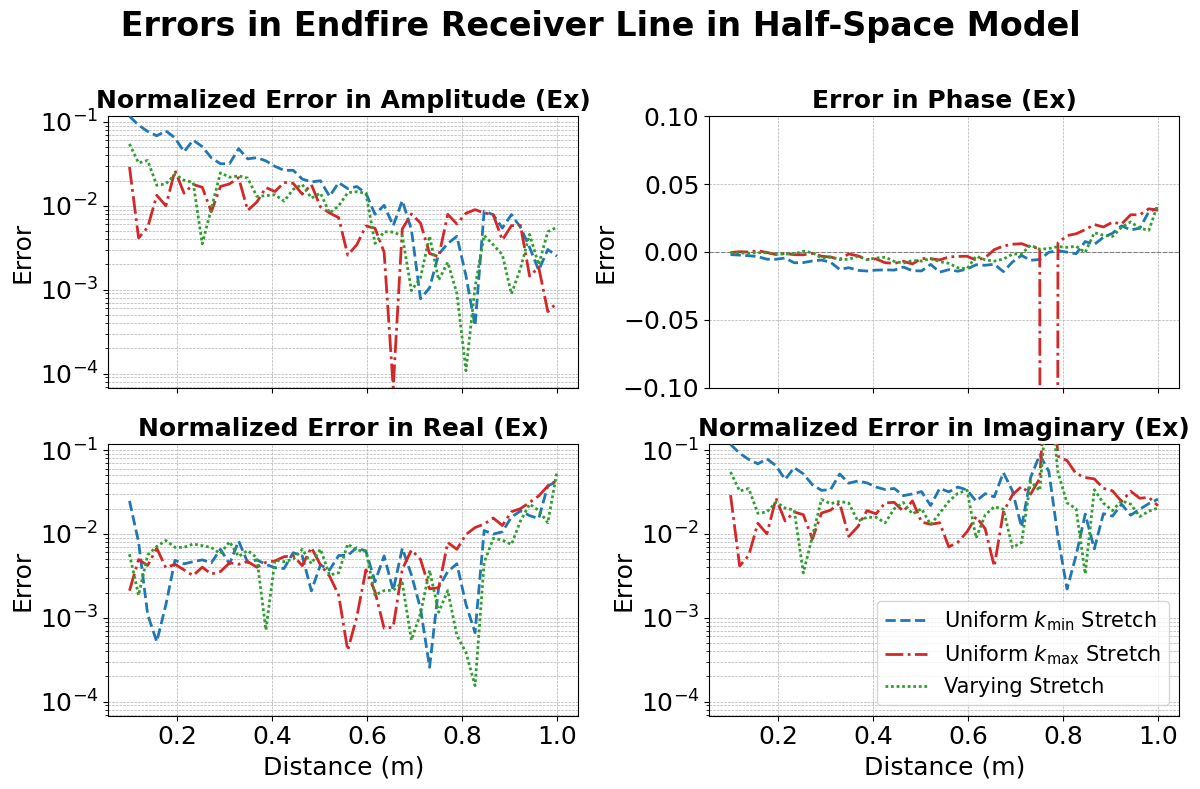

In [5]:
analytical_file = os.path.join(analytical_folder, "Exx_single_freq_4_100MHz_NR.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)

# Broadside
abs_broadside = analytical_lines[:, 5]
real_broadside = -1*analytical_lines[:, 7]
imag_broadside = -1*analytical_lines[:, 8]
phase_broadside = np.arctan2(imag_broadside, real_broadside)

# Oblique
abs_45deg = analytical_lines[:, 9]
real_45deg = -1*analytical_lines[:, 11]
imag_45deg = -1*analytical_lines[:, 12]
phase_45deg = np.arctan2(imag_45deg, real_45deg)

dataset_evert = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'Evert'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'Evert'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'Evert')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

analytical_file = os.path.join(analytical_folder, "GPR-2001-4-dlf-NR.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)

# Broadside
abs_broadside = analytical_lines[:, 5]
real_broadside = -1*analytical_lines[:, 7]
imag_broadside = -1*analytical_lines[:, 8]
phase_broadside = np.arctan2(imag_broadside, real_broadside)

# Oblique
abs_45deg = analytical_lines[:, 9]
real_45deg = -1*analytical_lines[:, 11]
imag_45deg = -1*analytical_lines[:, 12]
phase_45deg = np.arctan2(imag_45deg, real_45deg)

dataset_empymod = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'empymod - 2001 DLF'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'empymod - 2001 DLF'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'empymod - 2001 DLF')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

electric_file = os.path.join(base_folder, "out_HF_l1d_l2PML_CO_BA", "electric_fields_receiver_line.txt")
e_data_elfe_1 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_HF_l1d_l2PML_CO_BK", "electric_fields_receiver_line.txt")
e_data_elfe_2 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_HF_l1d_l2PML_CO_F", "electric_fields_receiver_line.txt")
e_data_elfe_3 = np.loadtxt(electric_file)

e_data_elfe_all = [e_data_elfe_1, e_data_elfe_2, e_data_elfe_3]

labels = [
    r'Uniform $k_\text{min}$ Stretch',
    r'Uniform $k_\text{max}$ Stretch',
    r'Varying Stretch',
]

# Allow custom number of receivers for each data set
num_rec_ef_list = [48] * len(e_data_elfe_all)
num_rec_bs_list = [0] * len(e_data_elfe_all)
num_rec_ob_list = [0] * len(e_data_elfe_all)

dataset_elfe_4 = []
for i, e_data_elfe in enumerate(e_data_elfe_all):
    num_rec_ef = num_rec_ef_list[i]

    rec_x_elfe = e_data_elfe[:, 0]
    rec_y_elfe = e_data_elfe[:, 1]
    real_Ex_elfe = e_data_elfe[:, 4]
    imag_Ex_elfe = e_data_elfe[:, 5]
    abs_Ex_elfe = np.abs(real_Ex_elfe + 1j * imag_Ex_elfe)
    phase_Ex_elfe = np.angle(real_Ex_elfe + 1j * imag_Ex_elfe)

    # Endfire
    i_rx_ef = 0
    abs_ef = abs_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    phase_ef = phase_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    real_ef = real_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    imag_ef = imag_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    r_ef = rec_x_elfe[i_rx_ef:i_rx_ef + num_rec_ef]

    dataset_elfe_4.append((abs_ef, phase_ef, real_ef, imag_ef, 'Endfire', r_ef, labels[i]))

# Use datasets from Evert, empymod, and elfe for Endfire
datasets_4 = [ds for ds in dataset_evert + dataset_empymod if ds[4] == 'Endfire']
datasets_4 += dataset_elfe_4

orientation = 'Endfire'
fname = f"2_co.png"
receiver_line_plot(datasets_4, 
                quantities, 
                postprocess_folder, 
                fname=fname, 
                orientation=orientation, 
                suptitle=f"{orientation} Receiver Line in Half-Space Model", 
                color_list=[0,1,2])

fname = f"2_co_error.png"
receiver_line_error_plot(datasets_4,
                dataset_evert[0],  # Use Evert as reference
                quantities, 
                postprocess_folder, 
                fname=fname, 
                orientation=orientation, 
                suptitle=f" Errors in {orientation} Receiver Line in Half-Space Model", 
                color_list=[0,1,2])



## l20

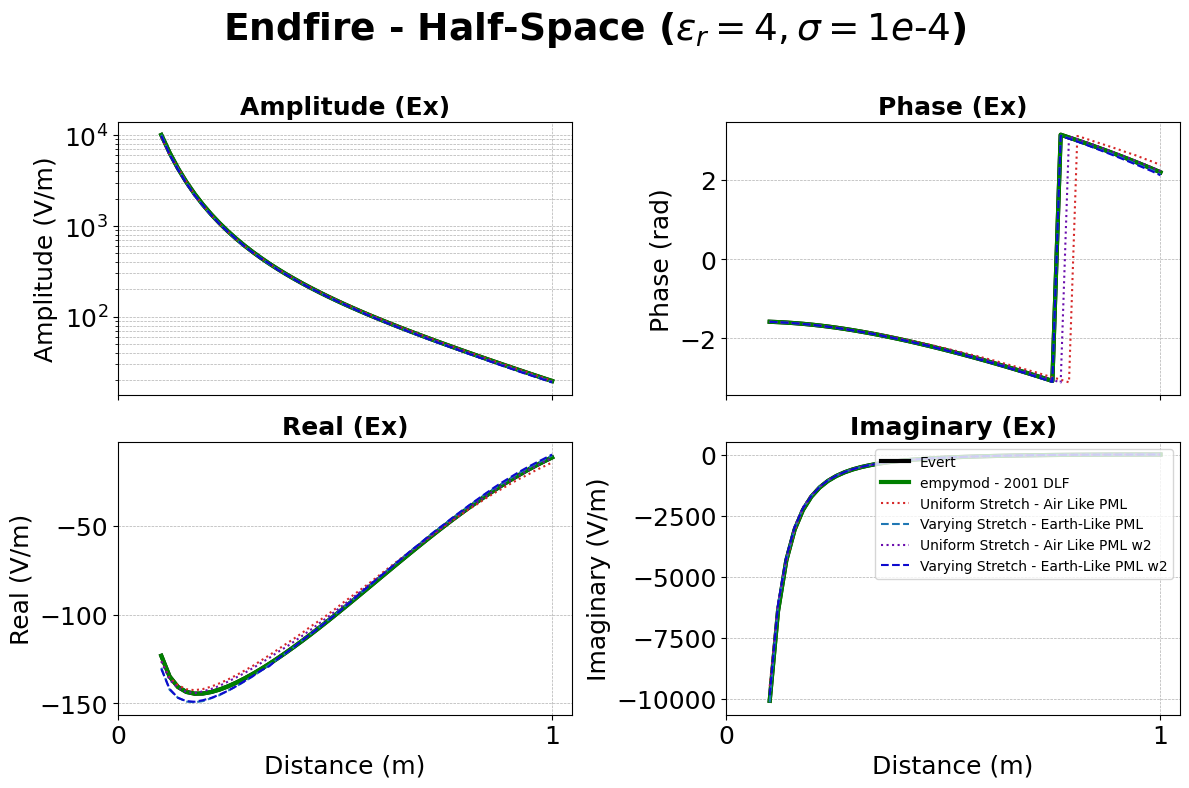

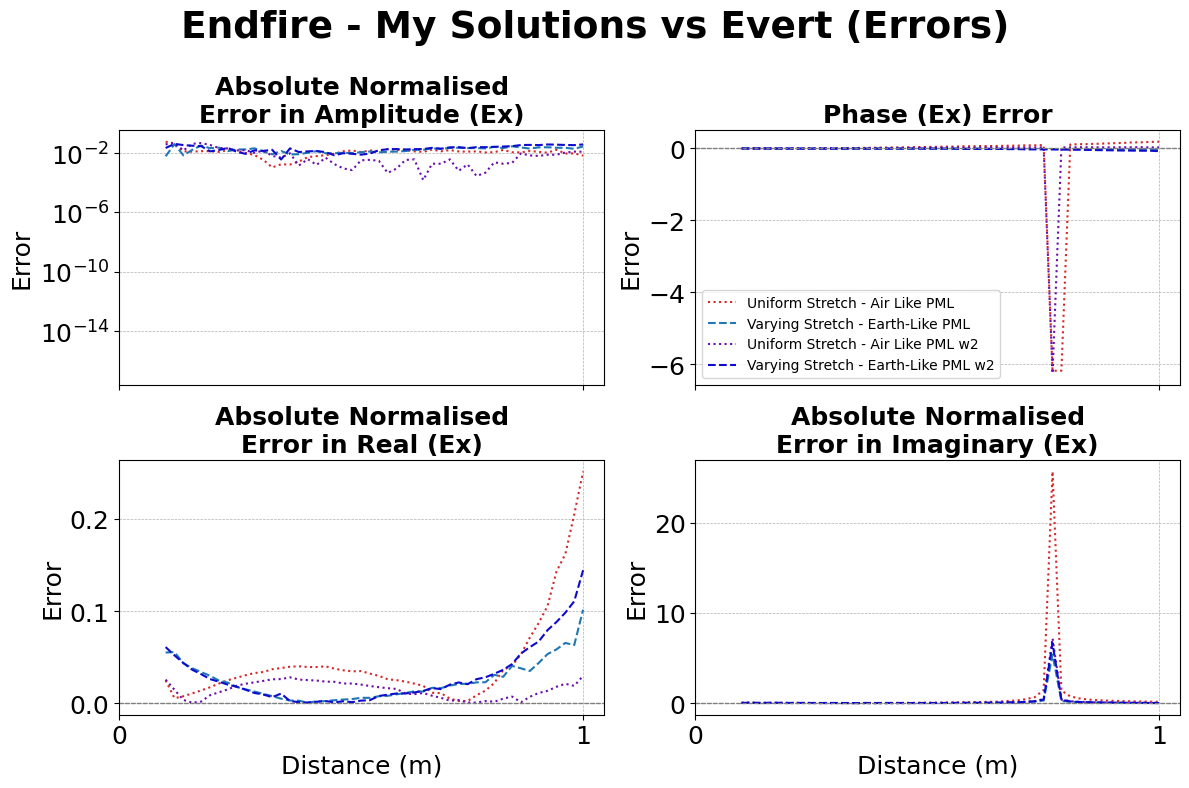

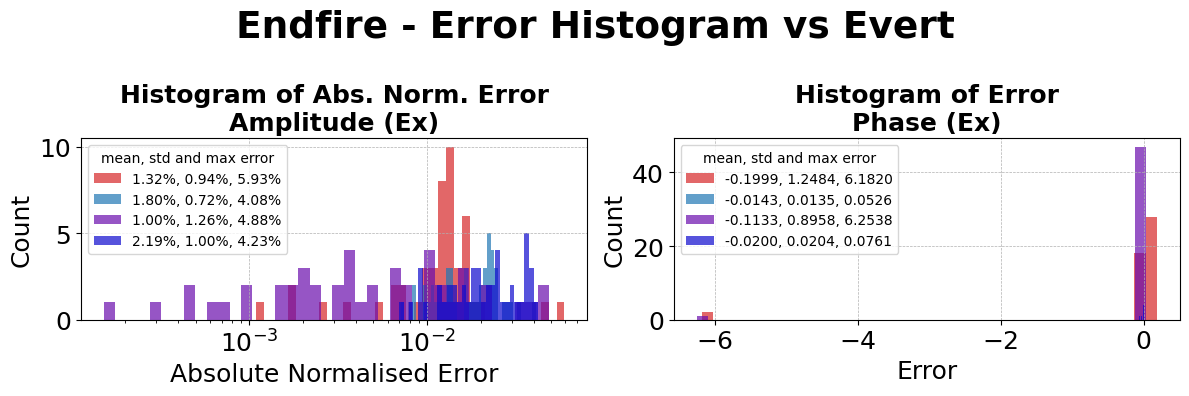

In [9]:
analytical_file = os.path.join(analytical_folder, "Exx_single_freq_4_100MHz_NR.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)

# Broadside
abs_broadside = analytical_lines[:, 5]
real_broadside = -1*analytical_lines[:, 7]
imag_broadside = -1*analytical_lines[:, 8]
phase_broadside = np.arctan2(imag_broadside, real_broadside)

# Oblique
abs_45deg = analytical_lines[:, 9]
real_45deg = -1*analytical_lines[:, 11]
imag_45deg = -1*analytical_lines[:, 12]
phase_45deg = np.arctan2(imag_45deg, real_45deg)

dataset_evert = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'Evert'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'Evert'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'Evert')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

analytical_file = os.path.join(analytical_folder, "GPR-2001-4-dlf-NR.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)

# Broadside
abs_broadside = analytical_lines[:, 5]
real_broadside = -1*analytical_lines[:, 7]
imag_broadside = -1*analytical_lines[:, 8]
phase_broadside = np.arctan2(imag_broadside, real_broadside)

# Oblique
abs_45deg = analytical_lines[:, 9]
real_45deg = -1*analytical_lines[:, 11]
imag_45deg = -1*analytical_lines[:, 12]
phase_45deg = np.arctan2(imag_45deg, real_45deg)

dataset_empymod = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'empymod - 2001 DLF'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'empymod - 2001 DLF'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'empymod - 2001 DLF')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

electric_file = os.path.join(base_folder, "out_HS_l20_BA_l10d_l10PML", "electric_fields_receiver_line.txt")
e_data_elfe_1 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_HS_l20_F_l10d_l10PML", "electric_fields_receiver_line.txt")
e_data_elfe_2 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_HS_l20_BA_l10d_l10PML_w4", "electric_fields_receiver_line.txt")
e_data_elfe_3 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_HS_l20_F_l10d_l10PML_w4", "electric_fields_receiver_line.txt")
e_data_elfe_4 = np.loadtxt(electric_file)

e_data_elfe_all = [e_data_elfe_1, e_data_elfe_2, e_data_elfe_3, e_data_elfe_4]

labels = [
    r'Uniform Stretch - Air Like PML',
    r'Varying Stretch - Earth-Like PML',
    r'Uniform Stretch - Air Like PML w2',
    r'Varying Stretch - Earth-Like PML w2',
    ]

# Allow custom number of receivers for each data set
num_rec_ef_list = [256] * len(e_data_elfe_all)
num_rec_bs_list = [0] * len(e_data_elfe_all)
num_rec_ob_list = [0] * len(e_data_elfe_all)

dataset_elfe_4 = []
for i, e_data_elfe in enumerate(e_data_elfe_all):
    num_rec_ef = num_rec_ef_list[i]

    rec_x_elfe = e_data_elfe[:, 0]
    rec_y_elfe = e_data_elfe[:, 1]
    real_Ex_elfe = e_data_elfe[:, 4]
    imag_Ex_elfe = e_data_elfe[:, 5]
    abs_Ex_elfe = np.abs(real_Ex_elfe + 1j * imag_Ex_elfe)
    phase_Ex_elfe = np.angle(real_Ex_elfe + 1j * imag_Ex_elfe)

    # Endfire
    i_rx_ef = 0
    abs_ef = abs_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    phase_ef = phase_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    real_ef = real_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    imag_ef = imag_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    r_ef = rec_x_elfe[i_rx_ef:i_rx_ef + num_rec_ef]

    dataset_elfe_4.append((abs_ef, phase_ef, real_ef, imag_ef, 'Endfire', r_ef, labels[i]))

# Use datasets from Evert, empymod, and elfe for Endfire
datasets_4 = [ds for ds in dataset_evert + dataset_empymod if ds[4] == 'Endfire']
datasets_4 += dataset_elfe_4

font_suptitle = 27
font_label = 18
font_tick = 18
font_legend = 10
mark_size = 2

# Style options
colors = ['#000000', 'green', '#d62728',  '#1f77b4', '#6a0dad', "#0e0ace", "#ff00b3"]
linestyles = ['-', '--', ':', '--', ':', '--', ':']
markers = ['', 'o', 's', 'v', 'X', 'D', 'P']

# Style options for different data origins
origin_styles = {
    'Evert': {'color': colors[0], 'linestyle': linestyles[0], 'marker': markers[0]},
    'empymod - 2001 DLF': {'color': colors[1], 'linestyle': linestyles[0], 'marker': markers[0]},
    labels[0]: {'color': colors[2], 'linestyle': linestyles[2], 'marker': ''},
    labels[1]: {'color': colors[3], 'linestyle': linestyles[3], 'marker': ''},
    labels[2]: {'color': colors[4], 'linestyle': linestyles[4], 'marker': ''},
    labels[3]: {'color': colors[5], 'linestyle': linestyles[5], 'marker': ''},
}

normal_lw = 2.0
orientation = 'Endfire'
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for j, (title, ylabel) in enumerate(quantities):
    ax = axes[j // 2, j % 2]
    for ds in datasets_4:
        amp, phase, real, imag, label, axis, source = ds
        style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})
        plot_label = source
        data = [amp, phase, real, imag][j]
        lw = normal_lw * 1.5 if source in ['Evert', 'empymod - 2001 DLF'] else normal_lw * 0.75
        if j == 0:
            ax.semilogy(axis, data, label=plot_label, color=style['color'],
                        linestyle=style['linestyle'], marker=style['marker'], linewidth=lw, markersize=mark_size)
            ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        else:
            ax.plot(axis, data, label=plot_label, color=style['color'],
                    linestyle=style['linestyle'], marker=style['marker'], linewidth=lw, markersize=mark_size)
            ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_title(title, fontsize=font_label, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=font_label)
    if j // 2 == 1:
        ax.set_xlabel('Distance (m)', fontsize=font_label)
    if axis.size > 0:
        xticks = np.arange(np.floor(axis.min() * 2) / 2, np.ceil(axis.max() * 2) / 2 + 0.01, 1)
        ax.set_xticks(xticks)
    ax.tick_params(axis='both', which='major', labelsize=font_tick)
    if j == 3:
        ax.legend(fontsize=font_legend, loc='upper right')
fig.suptitle(f"{orientation} - Half-Space ($\\varepsilon_r=4, \\sigma=1e\\text{{-}}4$)", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fname = f"3_comparison_{orientation.lower()}.png"
plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
plt.show()


# Helper function to compute errors with interpolation only if radii differ
def compute_errors_with_interp(ref, elfe):
    errors = []
    for idx in range(4):  # amp, phase, real, imag
        ref_data = ref[idx]
        elfe_data = elfe[idx]
        ref_r = ref[5]
        elfe_r = elfe[5]
        # Interpolate reference data if radii do not match
        if len(ref_r) != len(elfe_r) or not np.allclose(ref_r, elfe_r):
            ref_data_interp = np.interp(elfe_r, ref_r, ref_data)
        else:
            ref_data_interp = ref_data
        if idx in [0, 2, 3]:
            with np.errstate(divide='ignore', invalid='ignore'):
                err = np.abs(elfe_data - ref_data_interp) / np.abs(ref_data_interp)
                err[~np.isfinite(err)] = np.nan
        else:
            err = elfe_data - ref_data_interp
        errors.append(err)
    errors.append(elfe[5])
    return tuple(errors)

# Only plot Endfire orientation
orientation = 'Endfire'

# Select only Endfire datasets from elfe
elfe_endfire = [ds for ds in dataset_elfe_4 if ds[4] == orientation]

# Plot errors vs Evert
fig_evert, axes_evert = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ds in elfe_endfire:
    amp, phase, real, imag, _, axis, source = ds
    style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})
    lw = normal_lw * 0.75

    amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert, r_err_evert = compute_errors_with_interp(dataset_evert[0], ds)
    err_data_evert = [amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert]

    for k, ax in enumerate(axes_evert.flat):
        # Plot error curves
        ax.plot(r_err_evert, err_data_evert[k],
                label=source,
                color=style['color'],
                linestyle=style['linestyle'],
                marker=style['marker'],
                linewidth=lw, markersize=mark_size)
        ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
        ax.grid(True, linestyle='--', linewidth=0.5)
        if k == 0:
            ax.set_yscale('log')
        title_base = quantities[k][0]
        if k in [0, 2, 3]:
            ax.set_title(f"Absolute Normalised\nError in {title_base}",
                         fontsize=font_label, fontweight='bold')
        else:
            ax.set_title(f"{title_base} Error",
                         fontsize=font_label, fontweight='bold')
        if k // 2 == 1:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        ax.set_ylabel('Error', fontsize=font_label)
        if r_err_evert.size:
            start = np.floor(r_err_evert.min() * 2) / 2
            stop = np.ceil(r_err_evert.max() * 2) / 2 + 0.01
            ax.set_xticks(np.arange(start, stop, 1.0))
        ax.tick_params(axis='both', which='major', labelsize=font_tick)

axes_evert[0, 1].legend(fontsize=font_legend, loc='best')
fig_evert.suptitle(f"{orientation} - My Solutions vs Evert (Errors)",
                   fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
fname_evert = f"3_elfe_vs_evert_{orientation.lower()}_error.png"
plt.savefig(os.path.join(postprocess_folder, fname_evert), dpi=300)
plt.show()

# Plot histogram of errors for each quantity (amp, phase) vs Evert
fig_hist, axes_hist = plt.subplots(1, 2, figsize=(12, 4))
for ds in elfe_endfire:
    amp, phase, real, imag, _, axis, source = ds
    style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})

    amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert, r_err_evert = compute_errors_with_interp(dataset_evert[0], ds)
    err_data_evert = [amp_err_evert, phase_err_evert]

    for k, ax in enumerate(axes_hist.flat):
        # Remove NaNs/Infs for histogram
        err_flat = err_data_evert[k][np.isfinite(err_data_evert[k])]
        # Use log for amplitude error histogram
        if k == 0:
            bins = np.logspace(np.log10(np.nanmin(err_flat[err_flat > 0])), np.log10(np.nanmax(err_flat)), 40)
            mean_val = np.nanmean(err_flat) * 100
            std_val = np.nanstd(err_flat) * 100
            max_val = np.nanmax(err_flat) * 100
            label_stats = f"{mean_val:.2f}%, {std_val:.2f}%, {max_val:.2f}%"
            ax.hist(err_flat, bins=bins, color=style['color'], alpha=0.7, label=label_stats)
            ax.set_xscale('log')
        else:
            mean_val = np.nanmean(err_flat)
            std_val = np.nanstd(err_flat)
            max_val = np.nanmax(np.abs(err_flat))
            label_stats = f"{mean_val:.4f}, {std_val:.4f}, {max_val:.4f}"
            ax.hist(err_flat, bins=40, color=style['color'], alpha=0.7, label=label_stats)
        title_base = quantities[k][0]
        if k == 0:
            ax.set_title(f"Histogram of Abs. Norm. Error\n{title_base}", fontsize=font_label, fontweight='bold')
            ax.set_xlabel('Absolute Normalised Error', fontsize=font_label)
        else:
            ax.set_title(f"Histogram of Error\n{title_base}", fontsize=font_label, fontweight='bold')
            ax.set_xlabel('Error', fontsize=font_label)
        ax.set_ylabel('Count', fontsize=font_label)
        legend = ax.legend(fontsize=font_legend, title="mean, std and max error")
        ax.grid(True, linestyle='--', linewidth=0.5)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)

fig_hist.suptitle(f"{orientation} - Error Histogram vs Evert", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fname_hist = f"3_elfe_vs_evert_{orientation.lower()}_error_hist.png"
plt.savefig(os.path.join(postprocess_folder, fname_hist), dpi=300)
plt.show()
